In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# ========== PREPROCESSING OF DATASET ============
"""
Preprocess MRI-to-CT dataset on Kaggle.
Reads patient folders under /Task1/brain,
checks for .nii files (mr.nii, ct.nii, mask.nii),
and builds a list of patient records.
"""

import gzip
import shutil
from pathlib import Path
from tqdm import tqdm

# --- 1. Configuration ---
# Base path to the extracted dataset folder (brain anatomy only)
EXTRACT_PATH = Path("/kaggle/input/mri-to-ct-project/Task1/brain")

# --- 2. Find all patient directories ---
print(f"\n--> Searching for patient directories in {EXTRACT_PATH}")
patient_dirs = [p for p in EXTRACT_PATH.iterdir() if p.is_dir()]

all_patients_data = []

# --- 3. Process patient data ---
print("\n--> Finding patient scans and decompressing .nii.gz if any...")

for patient_dir in tqdm(patient_dirs, desc="Processing Patients"):
    mr_gz_path = patient_dir / 'mr.nii.gz'
    ct_gz_path = patient_dir / 'ct.nii.gz'

    mr_path = patient_dir / 'mr.nii'
    ct_path = patient_dir / 'ct.nii'
    mask_path = patient_dir / 'mask.nii'

    # Decompress mr.nii.gz to mr.nii if needed
    if mr_gz_path.exists() and not mr_path.exists():
        with gzip.open(mr_gz_path, 'rb') as f_in, open(mr_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    # Decompress ct.nii.gz to ct.nii if needed
    if ct_gz_path.exists() and not ct_path.exists():
        with gzip.open(ct_gz_path, 'rb') as f_in, open(ct_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    # Collect patient record if files exist
    record = {
        'id': patient_dir.name,
        'path': str(patient_dir),
        'mr_path': str(mr_path) if mr_path.exists() else None,
        'ct_path': str(ct_path) if ct_path.exists() else None,
        'mask_path': str(mask_path) if mask_path.exists() else None,
        'anatomy': 'brain',  # Update if adding pelvis or others
    }

    all_patients_data.append(record)

# --- 4. Final summary ---
print("\n" + "="*50)
print("Preprocessing complete!")
print(f"Total patient records found: {len(all_patients_data)}")
if all_patients_data:
    print("\nExample patient record:")
    print(all_patients_data[0])
print("="*50)



--> Searching for patient directories in /kaggle/input/mri-to-ct-project/Task1/brain

--> Finding patient scans and decompressing .nii.gz if any...


Processing Patients: 100%|██████████| 181/181 [00:00<00:00, 448.20it/s]


Preprocessing complete!
Total patient records found: 181

Example patient record:
{'id': '1BC090', 'path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090', 'mr_path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090/mr.nii', 'ct_path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090/ct.nii', 'mask_path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090/mask.nii', 'anatomy': 'brain'}


In [3]:
# =============  ENHANCED BRAIN SLICING ==========================
            
"""
Processes ONLY brain scans from Task1 on Kaggle
and saves only useful slices with meaningful anatomical content.
"""

import nibabel as nib
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import os
import shutil
import re

# --- 1. Configuration ---
INPUT_DATA_PATH = Path('/kaggle/input/mri-to-ct-project/Task1/brain')  # Corrected path to match your dataset
OUTPUT_SLICES_PATH = Path('/kaggle/working/processed_slices')

# Check input path existence early
if not INPUT_DATA_PATH.exists():
    raise FileNotFoundError(f"Input data path {INPUT_DATA_PATH} does not exist. Check your dataset extraction.")

# --- !! CLEANUP FIRST !! ---
if OUTPUT_SLICES_PATH.exists():
    print("--> Removing old 'processed_slices' directory for fresh processing...")
    shutil.rmtree(OUTPUT_SLICES_PATH)
    print("Cleanup complete.")

# Create output directories
PATH_TRAIN_A = OUTPUT_SLICES_PATH / 'trainA'  # MRI
PATH_TRAIN_B = OUTPUT_SLICES_PATH / 'trainB'  # CT
PATH_TRAIN_A.mkdir(parents=True, exist_ok=True)
PATH_TRAIN_B.mkdir(parents=True, exist_ok=True)
print(f"Output directories created at {PATH_TRAIN_A} and {PATH_TRAIN_B}")

# --- Helper functions ---

def sanitize_filename(name):
    """Sanitize strings for safe filenames."""
    return re.sub(r'[^a-zA-Z0-9_-]', '_', name)

def normalize_and_convert_to_uint8(image_data):
    """Normalize image data to 0-255 and convert to uint8."""
    lower_bound, upper_bound = np.percentile(image_data, [0.5, 99.5])
    clipped_data = np.clip(image_data, lower_bound, upper_bound)
    if upper_bound == lower_bound:
        return np.zeros_like(clipped_data, dtype=np.uint8)
    normalized_data = 255 * (clipped_data - lower_bound) / (upper_bound - lower_bound)
    return normalized_data.astype(np.uint8)

def is_useful_brain_slice(mri_slice, ct_slice,
                         mean_threshold=15,
                         variance_threshold=100,
                         brain_tissue_ratio=0.3):
    """Check if slice contains meaningful anatomical content."""
    if mri_slice.mean() < mean_threshold or ct_slice.mean() < mean_threshold:
        return False
    if mri_slice.var() < variance_threshold or ct_slice.var() < variance_threshold:
        return False

    mri_tissue = np.sum(mri_slice > 20) / mri_slice.size
    ct_tissue = np.sum(ct_slice > 20) / ct_slice.size
    if mri_tissue < brain_tissue_ratio or ct_tissue < brain_tissue_ratio:
        return False
    if np.ptp(mri_slice) < 30 or np.ptp(ct_slice) < 30:
        return False
    return True

def get_middle_slice_range(total_slices, coverage=0.6):
    """Focus on middle portion of brain with most anatomical detail."""
    start = int(total_slices * (1 - coverage) / 2)
    end = int(total_slices * (1 + coverage) / 2)
    return start, end

# --- Main Processing Logic ---
print("\n--> Starting enhanced 3D to 2D slice conversion for BRAIN DATA ONLY...")
print("Filter criteria: Mean >15, Variance >100, Brain tissue ratio >30%")

# Look for patient directories directly in the brain folder
patient_dirs = [p for p in INPUT_DATA_PATH.iterdir() if p.is_dir()]
mri_files = []

for patient_dir in patient_dirs:
    mr_file = patient_dir / 'mr.nii'
    if mr_file.exists():
        mri_files.append(mr_file)

if not mri_files:
    print("\n CRITICAL ERROR: No brain 'mr.nii' files found.")
    print("Please ensure your data structure is correct.")
else:
    print(f"Found {len(mri_files)} paired BRAIN scans to process.")

    slices_saved_count = 0
    total_slices_processed = 0
    skipped_volumes = 0

    for mri_path in tqdm(mri_files, desc="Processing Brain Volumes", disable=False):
        ct_path = mri_path.with_name('ct.nii')
        if not ct_path.exists():
            skipped_volumes += 1
            continue

        try:
            mri_data = nib.load(mri_path).get_fdata()
            ct_data = nib.load(ct_path).get_fdata()

            total_slices = mri_data.shape[2]
            start_idx, end_idx = get_middle_slice_range(total_slices)

            for i in range(start_idx, end_idx):
                total_slices_processed += 1

                mri_slice = normalize_and_convert_to_uint8(mri_data[:, :, i])
                ct_slice = normalize_and_convert_to_uint8(ct_data[:, :, i])

                if is_useful_brain_slice(mri_slice, ct_slice):
                    filename = f"{sanitize_filename(mri_path.parent.name)}_slice_{i:03d}.png"
                    cv2.imwrite(str(PATH_TRAIN_A / filename), mri_slice)
                    cv2.imwrite(str(PATH_TRAIN_B / filename), ct_slice)
                    slices_saved_count += 1

        except Exception as e:
            print(f"Error processing {mri_path}: {e}")
            skipped_volumes += 1

    # --- Summary ---
    print("\n" + "="*70)
    print("Enhanced Brain-Only Slice Processing Complete!")
    print("="*70)
    print(f" Volumes processed: {len(mri_files) - skipped_volumes}")
    print(f"  Volumes skipped: {skipped_volumes}")
    print(f" Total slices examined: {total_slices_processed}")
    print(f" Useful slices saved: {slices_saved_count}")
    if total_slices_processed > 0:
        print(f" Selection ratio: {slices_saved_count/total_slices_processed*100:.1f}%")
    print("="*70)

    if slices_saved_count > 0:
        print("\n Dataset quality improved and ready for training!")
    else:
        print("\n No slices met the criteria. Consider lowering thresholds.")


Output directories created at /kaggle/working/processed_slices/trainA and /kaggle/working/processed_slices/trainB

--> Starting enhanced 3D to 2D slice conversion for BRAIN DATA ONLY...
Filter criteria: Mean >15, Variance >100, Brain tissue ratio >30%
Found 180 paired BRAIN scans to process.


Processing Brain Volumes: 100%|██████████| 180/180 [04:07<00:00,  1.38s/it]


Enhanced Brain-Only Slice Processing Complete!
 Volumes processed: 180
  Volumes skipped: 0
 Total slices examined: 20749
 Useful slices saved: 17669
 Selection ratio: 85.2%

 Dataset quality improved and ready for training!


 Brain-only dataset found. Starting EDA...
Analyzing sample pair: 1BA022_slice_083.png


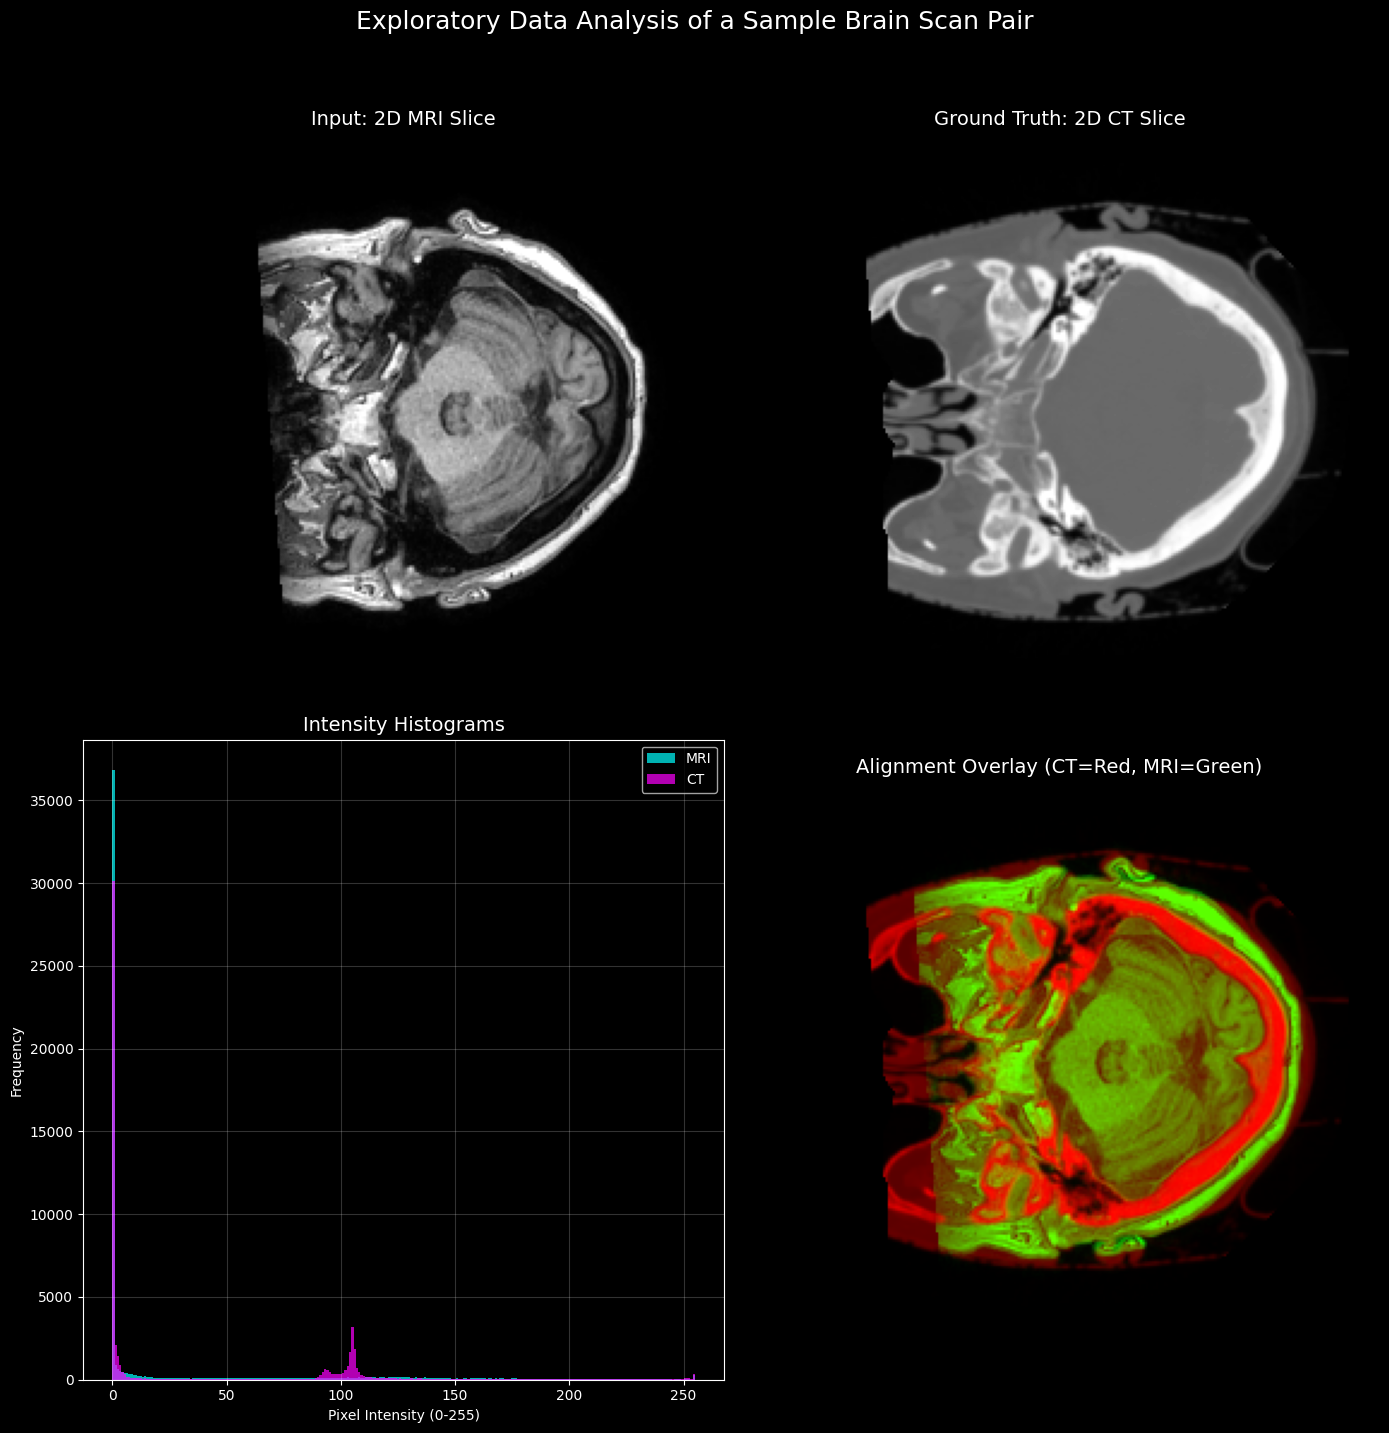

In [4]:
# =============== EXPLORATORY DATA ANALYSIS ===================== 
"""
This script performs Exploratory Data Analysis (EDA) on the 2D brain slices
prepared in the previous step.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import os

# --- 1. Configuration ---
SLICES_PATH = Path('/kaggle/working/processed_slices')  # Confirm this matches where your slices are saved
MRI_SLICES_PATH = SLICES_PATH / 'trainA'
CT_SLICES_PATH = SLICES_PATH / 'trainB'

# --- 2. Pre-run Check ---
if not MRI_SLICES_PATH.exists() or not os.listdir(MRI_SLICES_PATH):
    print(f" ERROR: The directory '{MRI_SLICES_PATH}' is empty or does not exist.")
    print("Please ensure the slicing script (02_enhanced_brain_slicing_kaggle.py) ran successfully.")
else:
    print(" Brain-only dataset found. Starting EDA...")

    # --- 3. Load a Random Sample Pair ---
    all_mri_files = list(MRI_SLICES_PATH.glob('*.png'))
    random_mri_path = random.choice(all_mri_files)
    random_ct_path = CT_SLICES_PATH / random_mri_path.name

    print(f"Analyzing sample pair: {random_mri_path.name}")

    # Load images in grayscale
    mri_slice = cv2.imread(str(random_mri_path), cv2.IMREAD_GRAYSCALE)
    ct_slice = cv2.imread(str(random_ct_path), cv2.IMREAD_GRAYSCALE)

    # --- 4. Perform and Visualize the EDA ---
    plt.style.use('dark_background')
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    fig.suptitle('Exploratory Data Analysis of a Sample Brain Scan Pair', fontsize=18, y=1.02)

    # a) MRI Slice
    axes[0, 0].imshow(mri_slice, cmap='gray')
    axes[0, 0].set_title('Input: 2D MRI Slice', fontsize=14)
    axes[0, 0].axis('off')

    # b) CT Slice
    axes[0, 1].imshow(ct_slice, cmap='gray')
    axes[0, 1].set_title('Ground Truth: 2D CT Slice', fontsize=14)
    axes[0, 1].axis('off')

    # c) Intensity Histograms
    axes[1, 0].hist(mri_slice.ravel(), bins=256, color='cyan', alpha=0.7, label='MRI')
    axes[1, 0].hist(ct_slice.ravel(), bins=256, color='magenta', alpha=0.7, label='CT')
    axes[1, 0].set_title('Intensity Histograms', fontsize=14)
    axes[1, 0].set_xlabel('Pixel Intensity (0-255)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.2)

    # d) Overlay (CT=Red, MRI=Green)
    overlay_img = np.zeros((*mri_slice.shape, 3), dtype=np.uint8)
    overlay_img[..., 0] = ct_slice  # Red channel for CT
    overlay_img[..., 1] = mri_slice # Green channel for MRI

    axes[1, 1].imshow(overlay_img)
    axes[1, 1].set_title('Alignment Overlay (CT=Red, MRI=Green)', fontsize=14)
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()


In [5]:
# ==================== MODEL DEFINITION ======================
"""
Part 1: U-Net Encoder + Local Decoder Model Definition
- U-Net Encoder for feature extraction
- Local Decoder with refinement
"""

# --- Imports (PyTorch is pre-installed on Kaggle) ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
import os

# torchmetrics (install only if missing)
try:
    from torchmetrics import StructuralSimilarityIndexMeasure, MultiScaleStructuralSimilarityIndexMeasure
except ImportError:
    !pip install -q torchmetrics
    from torchmetrics import StructuralSimilarityIndexMeasure, MultiScaleStructuralSimilarityIndexMeasure

print(" Libraries imported successfully.")


# --- U-Net Encoder ---
class UNetEncoder(nn.Module):
    def __init__(self, in_channels=1):  # Fixed __init__ method name
        super(UNetEncoder, self).__init__()  # Fixed super() call
        
        def double_conv(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
        
        self.enc1 = double_conv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = double_conv(512, 1024)
    
    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        bottleneck = self.bottleneck(p4)
        return bottleneck, e4, e3, e2, e1

# --- Local Decoder ---
class LocalDecoder(nn.Module):
    def __init__(self, out_channels=1):  # Fixed __init__ method name
        super(LocalDecoder, self).__init__()  # Fixed super() call
        
        def up_conv(in_c, out_c):
            return nn.ConvTranspose2d(in_c, out_c, 2, 2)
        
        def double_conv(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
        
        self.up6 = up_conv(1024, 512); self.dec6 = double_conv(1024, 512)
        self.up7 = up_conv(512, 256);  self.dec7 = double_conv(512, 256)
        self.up8 = up_conv(256, 128);  self.dec8 = double_conv(256, 128)
        self.up9 = up_conv(128, 64);   self.dec9 = double_conv(128, 64)
        
        self.local_refine = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.final_conv = nn.Conv2d(16, out_channels, 1)
    
    def forward(self, bottleneck, e4, e3, e2, e1):
        u6 = self.up6(bottleneck); d6 = self.dec6(torch.cat([u6, e4], 1))
        u7 = self.up7(d6);         d7 = self.dec7(torch.cat([u7, e3], 1))
        u8 = self.up8(d7);         d8 = self.dec8(torch.cat([u8, e2], 1))
        u9 = self.up9(d8);         d9 = self.dec9(torch.cat([u9, e1], 1))
        refined = self.local_refine(d9)
        return self.final_conv(refined)

# --- Complete Model ---
class UNet_LocalDecoder(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):  # Fixed __init__ method name
        super(UNet_LocalDecoder, self).__init__()  # Fixed super() call
        self.encoder = UNetEncoder(in_channels)
        self.decoder = LocalDecoder(out_channels)
    
    def forward(self, x):
        bottleneck, e4, e3, e2, e1 = self.encoder(x)
        return self.decoder(bottleneck, e4, e3, e2, e1)



 Libraries imported successfully.


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from pathlib import Path
import random
import os


# --- Combined Loss Function ---
class CombinedLoss(nn.Module):
    """
    Combined Loss = L1 + SSIM + MS-SSIM
    """
    def __init__(self, l1_weight=0.5, ssim_weight=0.3, ms_ssim_weight=0.2):  # Fixed __init__ method name
        super(CombinedLoss, self).__init__()  # Fixed super() call
        self.l1_loss = nn.L1Loss()
        self.ssim = StructuralSimilarityIndexMeasure(data_range=1.0)
        self.ms_ssim = MultiScaleStructuralSimilarityIndexMeasure(data_range=1.0)
        self.l1_weight = l1_weight
        self.ssim_weight = ssim_weight
        self.ms_ssim_weight = ms_ssim_weight
    
    def forward(self, prediction, target):
        l1_val = self.l1_loss(prediction, target)
        ssim_val = self.ssim(prediction, target)
        ms_ssim_val = self.ms_ssim(prediction, target)
        ssim_loss = 1 - ssim_val
        ms_ssim_loss = 1 - ms_ssim_val
        total_loss = (self.l1_weight * l1_val +
                      self.ssim_weight * ssim_loss +
                      self.ms_ssim_weight * ms_ssim_loss)
        return total_loss, l1_val, ssim_val, ms_ssim_val

    
def compute_psnr(pred, target, max_val=2000.0):
    """
    PSNR for HU images. Assumes denormalized HU range [-1000, 1000].
    Adjust `max_val` if your HU range differs.
    """
    mse = torch.mean((pred - target) ** 2)
    if mse == 0:
        return torch.tensor(float('inf'))
    psnr = 20 * torch.log10(max_val / torch.sqrt(mse))
    return psnr


# --- HU Denormalization Helper ---
def denormalize_to_hu(tensor, min_val=-1000, max_val=2000):
    """
    Inverse of min-max normalization to [0,1].
    If your pipeline uses [-1,1] normalization, adjust accordingly.
    """
    return tensor * (max_val - min_val) + min_val

print(" Kaggle-ready model & loss function defined.")


 Kaggle-ready model & loss function defined.


In [9]:
# ====================== FIXED DATA LOADING & TRAINING SETUP ==========================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import random
import os

# ====================== CONFIG ======================
# Paths
DATASET_PATH = Path('/kaggle/working/processed_slices')
BEST_MODEL_PATH = Path('/kaggle/working/best_mri_to_ct_model_FIXED.pth')
CHECKPOINT_DIR = Path('/kaggle/working/checkpoints_fixed')
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Training Hyperparameters
NUM_EPOCHS = 20
LEARNING_RATE = 2e-4
BATCH_SIZE = 16

# Device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


# ====================== DATASET CLASS ======================
class MRItoCTDataset(Dataset):
    """Custom PyTorch Dataset for paired MRI and CT images."""
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.mri_dir = self.root_dir / 'trainA'
        self.ct_dir = self.root_dir / 'trainB'
        self.mri_files = sorted(os.listdir(self.mri_dir))
        self.transform = transform
    
    def __len__(self):
        return len(self.mri_files)
    
    def __getitem__(self, idx):
        mri_path = self.mri_dir / self.mri_files[idx]
        ct_path = self.ct_dir / self.mri_files[idx]
        
        mri_image = Image.open(mri_path).convert("L")
        ct_image = Image.open(ct_path).convert("L")
        
        if self.transform:
            mri_image = self.transform(mri_image)
            ct_image = self.transform(ct_image)
        
        return mri_image, ct_image


# ====================== TRANSFORMS ======================
transform = transforms.Compose([
    transforms.Resize((256, 256), antialias=True),
    transforms.ToTensor()
])

# Load dataset
dataset = MRItoCTDataset(root_dir=DATASET_PATH, transform=transform)
print(f"Total dataset size: {len(dataset)} images")


# ====================== PATIENT-LEVEL SPLIT ======================
def create_patient_level_split(dataset, val_fraction=0.15, test_fraction=0.15):
    """Create train, val, and test subsets ensuring NO patient overlap"""
    
    # Extract unique patient IDs from dataset filenames
    all_files = dataset.mri_files
    patient_ids = list(set([f.split('_')[0] for f in all_files]))
    print(f"Total unique patients: {len(patient_ids)}")
    
    # Shuffle patients
    random.seed(42)
    random.shuffle(patient_ids)
    
    # Compute split sizes
    n_total = len(patient_ids)
    n_test = int(n_total * test_fraction)
    n_val = int(n_total * val_fraction)
    
    test_patient_ids = set(patient_ids[:n_test])
    val_patient_ids = set(patient_ids[n_test:n_test + n_val])
    train_patient_ids = set(patient_ids[n_test + n_val:])
    
    # Map slices to splits
    train_indices, val_indices, test_indices = [], [], []
    for idx, fname in enumerate(all_files):
        patient_id = fname.split('_')[0]
        if patient_id in train_patient_ids:
            train_indices.append(idx)
        elif patient_id in val_patient_ids:
            val_indices.append(idx)
        elif patient_id in test_patient_ids:
            test_indices.append(idx)
    
    # Create subsets
    train_subset = Subset(dataset, train_indices)
    val_subset = Subset(dataset, val_indices)
    test_subset = Subset(dataset, test_indices)
    
    # Verify no leakage
    overlap = train_patient_ids & val_patient_ids | val_patient_ids & test_patient_ids | train_patient_ids & test_patient_ids
    print(f"✅ PROPER SPLIT RESULTS:")
    print(f"   Train patients: {len(train_patient_ids)} | slices: {len(train_subset)}")
    print(f"   Val patients:   {len(val_patient_ids)} | slices: {len(val_subset)}")
    print(f"   Test patients:  {len(test_patient_ids)} | slices: {len(test_subset)}")
    print(f"   Patient overlap: {len(overlap)} (MUST be 0)")
    
    if len(overlap) == 0:
        print(" SUCCESS: No patient data leakage!")
    else:
        print(" ERROR: Patient overlap detected!")
    
    return train_subset, val_subset, test_subset


# Create proper split
train_dataset, val_dataset, test_dataset = create_patient_level_split(
    dataset, val_fraction=0.15, test_fraction=0.15
)

# ====================== DATALOADERS ======================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


# ====================== MODEL & OPTIMIZER ======================

model = UNet_LocalDecoder(in_channels=1, out_channels=1).to(device)
combined_loss_fn = CombinedLoss(l1_weight=1, ssim_weight=0.5).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.999))
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

print(" FIXED Training setup complete!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Using device: cuda
Total dataset size: 17669 images
Total unique patients: 180
✅ PROPER SPLIT RESULTS:
   Train patients: 126 | slices: 12210
   Val patients:   27 | slices: 2708
   Test patients:  27 | slices: 2751
   Patient overlap: 0 (MUST be 0)
 SUCCESS: No patient data leakage!
 FIXED Training setup complete!
Model parameters: 31,065,505



 Starting Enhanced U-Net Training with Local Decoder


Epoch [1/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.43it/s, val_loss=0.1274, val_ssim=0.8413]


   🌟 NEW BEST MODEL! Validation SSIM: 0.757648

📊 Epoch 1 Summary:
   • Train Loss: 0.255545 | Val Loss: 0.185674
   • Train SSIM: 0.663309 | Val SSIM: 0.757648
   • Train MAE (HU): 142.69 | Val MAE (HU): 106.09
   • Learning Rate: 2.00e-04
   • Best Val SSIM: 0.757648 (Epoch 1)


Epoch [2/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.45it/s, val_loss=0.1840, val_ssim=0.7141]



📊 Epoch 2 Summary:
   • Train Loss: 0.171665 | Val Loss: 0.179121
   • Train SSIM: 0.775716 | Val SSIM: 0.756957
   • Train MAE (HU): 102.23 | Val MAE (HU): 96.82
   • Learning Rate: 2.00e-04
   • Best Val SSIM: 0.757648 (Epoch 1)
   💾 Checkpoint saved: checkpoint_epoch_2.pth


...


📊 Epoch 3 Summary:
   • Train Loss: 0.160330 | Val Loss: 0.201124
   • Train SSIM: 0.794118 | Val SSIM: 0.754838
   • Train MAE (HU): 99.78 | Val MAE (HU): 130.99
   • Learning Rate: 2.00e-04
   • Best Val SSIM: 0.757648 (Epoch 1)


Epoch [4/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.47it/s, val_loss=0.1136, val_ssim=0.8293]


   🌟 NEW BEST MODEL! Validation SSIM: 0.797306

📊 Epoch 4 Summary:
   • Train Loss: 0.144922 | Val Loss: 0.150671
   • Train SSIM: 0.815251 | Val SSIM: 0.797306
   • Train MAE (HU): 92.83 | Val MAE (HU): 85.19
   • Learning Rate: 2.00e-04
   • Best Val SSIM: 0.797306 (Epoch 4)
   💾 Checkpoint saved: checkpoint_epoch_4.pth


Epoch [5/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.44it/s, val_loss=0.1007, val_ssim=0.8629]


   🌟 NEW BEST MODEL! Validation SSIM: 0.851141

📊 Epoch 5 Summary:
   • Train Loss: 0.125870 | Val Loss: 0.123049
   • Train SSIM: 0.842723 | Val SSIM: 0.851141
   • Train MAE (HU): 85.44 | Val MAE (HU): 89.54
   • Learning Rate: 2.00e-04
   • Best Val SSIM: 0.851141 (Epoch 5)


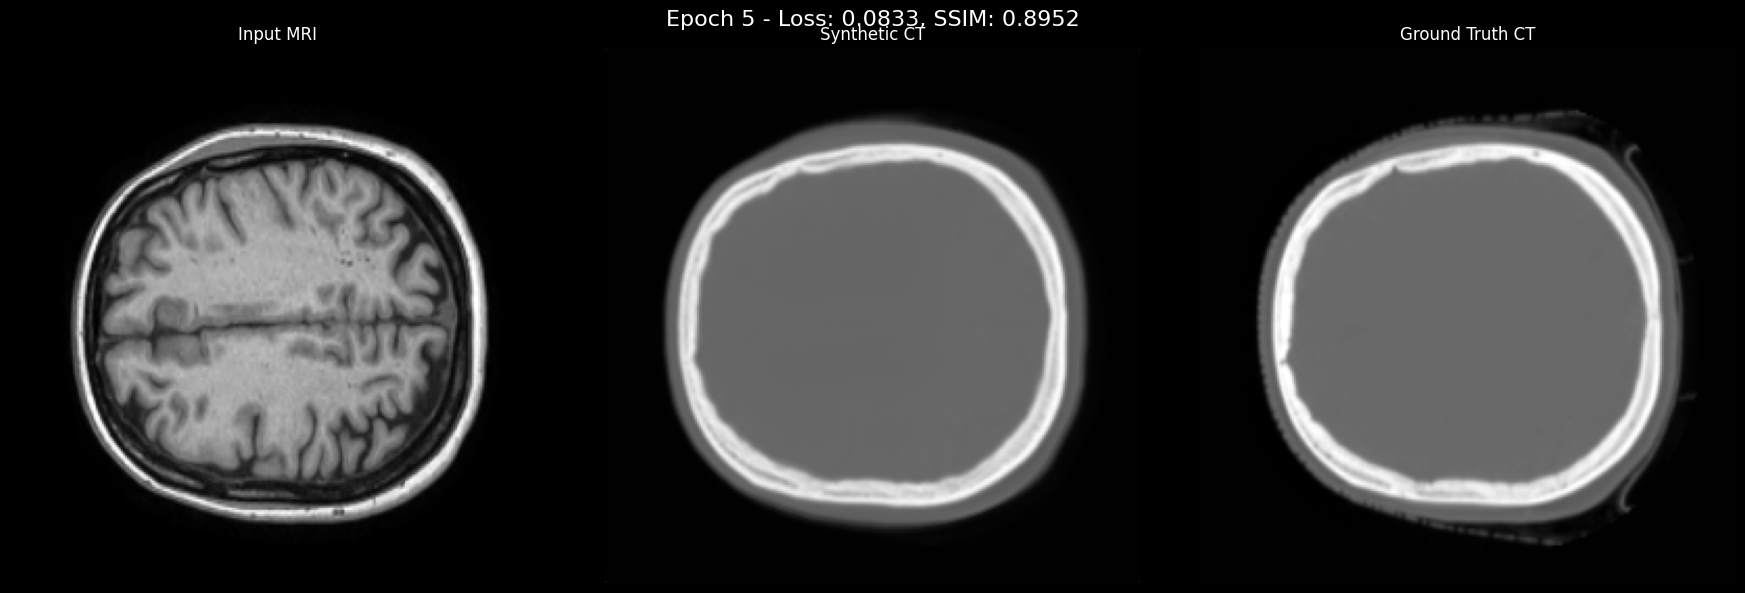

Epoch [6/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.44it/s, val_loss=0.0799, val_ssim=0.8859]



📊 Epoch 6 Summary:
   • Train Loss: 0.121142 | Val Loss: 0.119492
   • Train SSIM: 0.847027 | Val SSIM: 0.849109
   • Train MAE (HU): 82.00 | Val MAE (HU): 77.82
   • Learning Rate: 2.00e-04
   • Best Val SSIM: 0.851141 (Epoch 5)
   💾 Checkpoint saved: checkpoint_epoch_6.pth


Epoch [7/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.48it/s, val_loss=0.0761, val_ssim=0.8942]



📊 Epoch 7 Summary:
   • Train Loss: 0.112803 | Val Loss: 0.144376
   • Train SSIM: 0.858317 | Val SSIM: 0.801897
   • Train MAE (HU): 77.70 | Val MAE (HU): 81.36
   • Learning Rate: 2.00e-04
   • Best Val SSIM: 0.851141 (Epoch 5)


Epoch [8/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.46it/s, val_loss=0.0664, val_ssim=0.9132]



📊 Epoch 8 Summary:
   • Train Loss: 0.106238 | Val Loss: 0.123468
   • Train SSIM: 0.867249 | Val SSIM: 0.840716
   • Train MAE (HU): 74.23 | Val MAE (HU): 77.88
   • Learning Rate: 2.00e-04
   • Best Val SSIM: 0.851141 (Epoch 5)
   💾 Checkpoint saved: checkpoint_epoch_8.pth


Epoch [9/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.47it/s, val_loss=0.0782, val_ssim=0.8986]



📊 Epoch 9 Summary:
   • Train Loss: 0.102777 | Val Loss: 0.133727
   • Train SSIM: 0.870382 | Val SSIM: 0.825600
   • Train MAE (HU): 71.27 | Val MAE (HU): 79.77
   • Learning Rate: 1.00e-04
   • Best Val SSIM: 0.851141 (Epoch 5)


Epoch [10/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.48it/s, val_loss=0.0581, val_ssim=0.9263]


   🌟 NEW BEST MODEL! Validation SSIM: 0.869983

📊 Epoch 10 Summary:
   • Train Loss: 0.093381 | Val Loss: 0.102466
   • Train SSIM: 0.883423 | Val SSIM: 0.869983
   • Train MAE (HU): 66.00 | Val MAE (HU): 68.61
   • Learning Rate: 1.00e-04
   • Best Val SSIM: 0.869983 (Epoch 10)


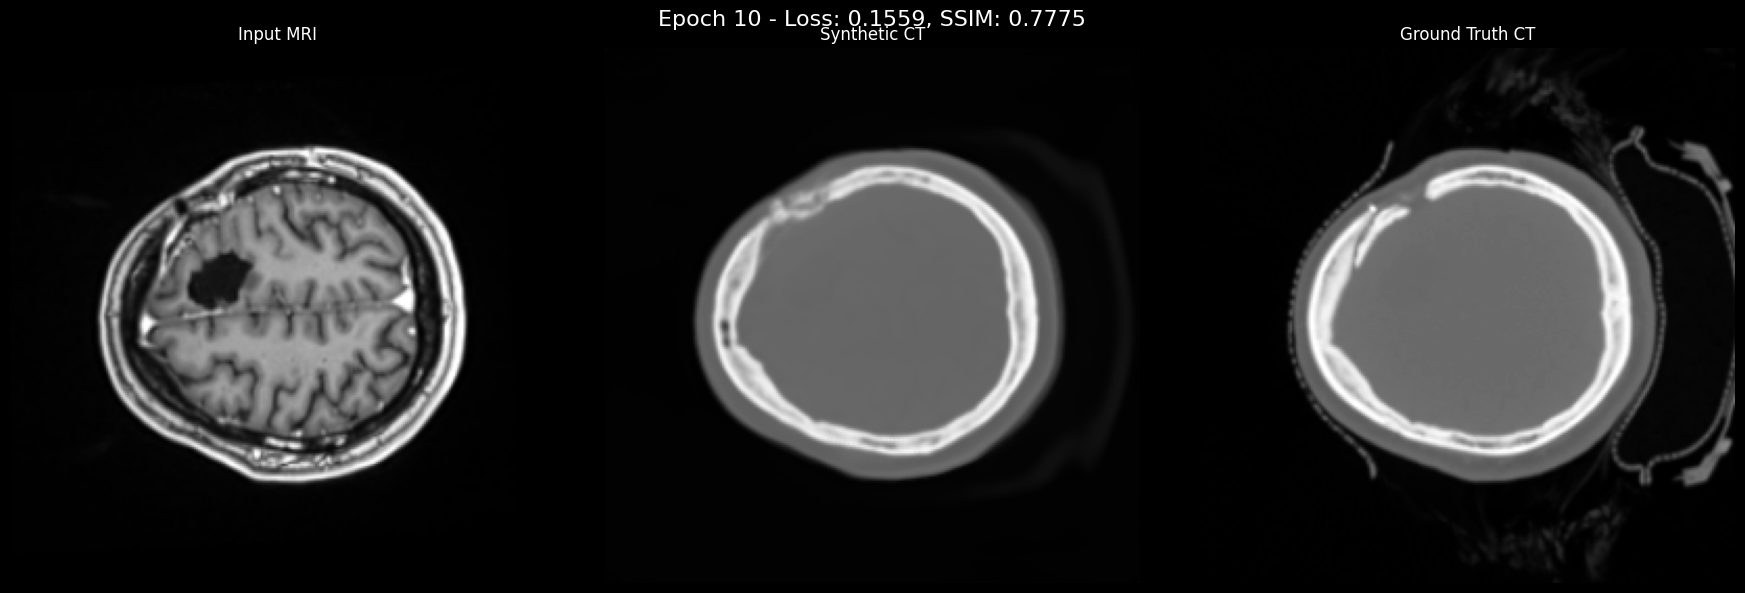

   💾 Checkpoint saved: checkpoint_epoch_10.pth


Epoch [11/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.49it/s, val_loss=0.0561, val_ssim=0.9337]



📊 Epoch 11 Summary:
   • Train Loss: 0.088828 | Val Loss: 0.107725
   • Train SSIM: 0.889191 | Val SSIM: 0.860378
   • Train MAE (HU): 63.38 | Val MAE (HU): 69.75
   • Learning Rate: 1.00e-04
   • Best Val SSIM: 0.869983 (Epoch 10)


Epoch [12/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.48it/s, val_loss=0.0434, val_ssim=0.9449]



📊 Epoch 12 Summary:
   • Train Loss: 0.086634 | Val Loss: 0.105425
   • Train SSIM: 0.890913 | Val SSIM: 0.863982
   • Train MAE (HU): 61.34 | Val MAE (HU): 68.41
   • Learning Rate: 1.00e-04
   • Best Val SSIM: 0.869983 (Epoch 10)
   💾 Checkpoint saved: checkpoint_epoch_12.pth


...


📊 Epoch 13 Summary:
   • Train Loss: 0.083781 | Val Loss: 0.105418
   • Train SSIM: 0.894349 | Val SSIM: 0.864977
   • Train MAE (HU): 59.63 | Val MAE (HU): 70.27
   • Learning Rate: 1.00e-04
   • Best Val SSIM: 0.869983 (Epoch 10)


Epoch [14/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.49it/s, val_loss=0.0542, val_ssim=0.9331]



📊 Epoch 14 Summary:
   • Train Loss: 0.079601 | Val Loss: 0.103753
   • Train SSIM: 0.899794 | Val SSIM: 0.867515
   • Train MAE (HU): 57.21 | Val MAE (HU): 69.65
   • Learning Rate: 1.00e-04
   • Best Val SSIM: 0.869983 (Epoch 10)
   💾 Checkpoint saved: checkpoint_epoch_14.pth


Epoch [15/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.51it/s, val_loss=0.0480, val_ssim=0.9442]



📊 Epoch 15 Summary:
   • Train Loss: 0.077004 | Val Loss: 0.110002
   • Train SSIM: 0.902904 | Val SSIM: 0.857998
   • Train MAE (HU): 55.71 | Val MAE (HU): 72.07
   • Learning Rate: 5.00e-05
   • Best Val SSIM: 0.869983 (Epoch 10)


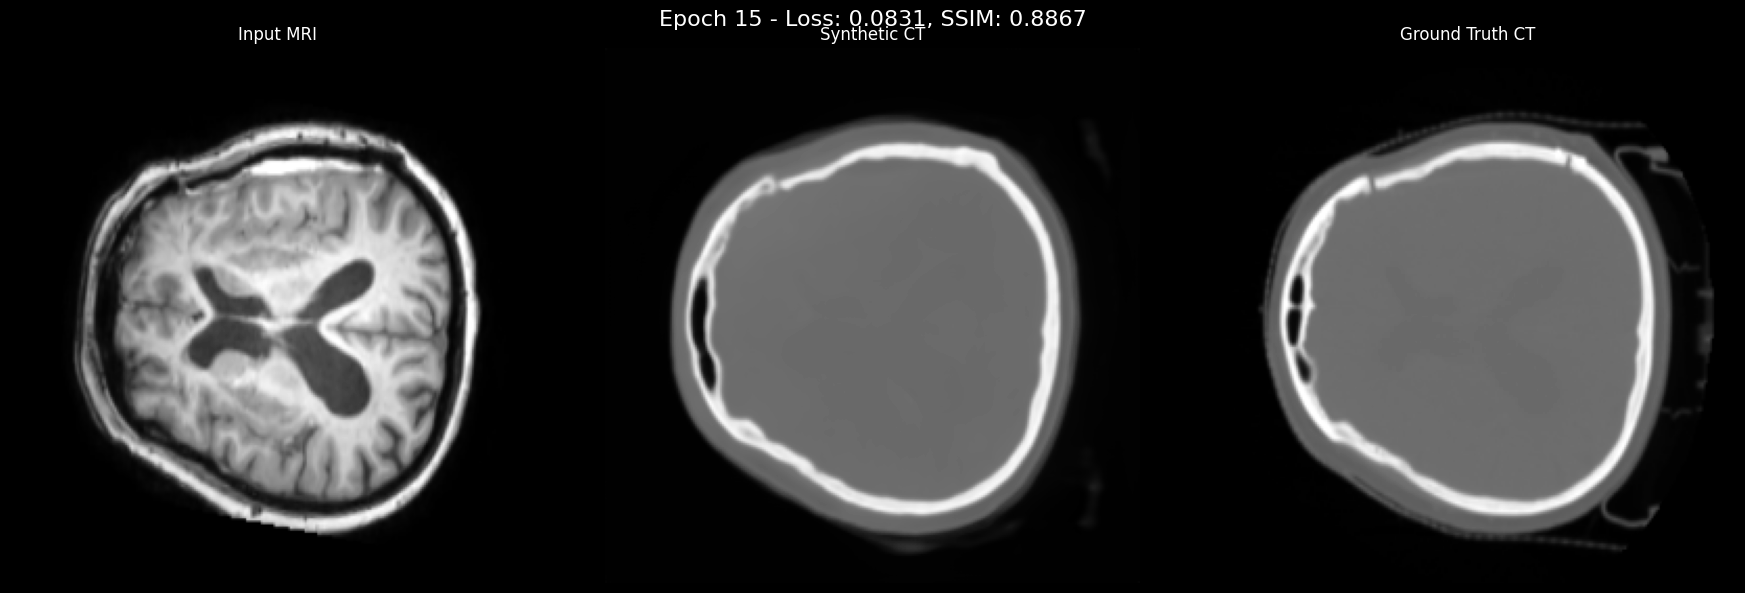

Epoch [16/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.50it/s, val_loss=0.0458, val_ssim=0.9452]



📊 Epoch 16 Summary:
   • Train Loss: 0.070075 | Val Loss: 0.103946
   • Train SSIM: 0.912337 | Val SSIM: 0.866220
   • Train MAE (HU): 51.87 | Val MAE (HU): 68.28
   • Learning Rate: 5.00e-05
   • Best Val SSIM: 0.869983 (Epoch 10)
   💾 Checkpoint saved: checkpoint_epoch_16.pth


Epoch [17/20] Validation: 100%|██████████| 170/170 [00:26<00:00,  6.51it/s, val_loss=0.0477, val_ssim=0.9402]



⏹ Early stopping at epoch 17

🎉 Training Complete!
 Final model saved to: /kaggle/working/final_mri_to_ct_model.pth
 Best model saved to: /kaggle/working/best_mri_to_ct_model.pth
 Results:
   • Best Validation SSIM: 0.869983 (Epoch 10)
   • Best Validation Loss: 0.102466
   • Final Training SSIM: 0.915662
   • Final Validation SSIM: 0.862591
   • Final Training MAE (HU): 50.21
   • Final Validation MAE (HU): 68.63


In [10]:
# ======================  TRAINING OF MODEL ==========================
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import numpy as np

# --- Visualization Function ---
def visualize_progress(model, val_dataset, device, epoch, combined_loss_fn):
    """Show qualitative results of MRI → Synthetic CT generation with metrics."""
    model.eval()
    
    # Pick a random validation sample
    sample_idx = random.randint(0, len(val_dataset) - 1)
    mri, ct = val_dataset[sample_idx]
    mri, ct = mri.unsqueeze(0).to(device), ct.unsqueeze(0).to(device)
    
    with torch.no_grad():
        predicted_ct = model(mri)
        loss, l1_val, ssim_val, ms_ssim_val = combined_loss_fn(predicted_ct, ct)
    
    # Prepare images for plotting
    mri = mri[0].cpu().squeeze()
    ct = ct[0].cpu().squeeze()
    predicted_ct = predicted_ct[0].cpu().squeeze()
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f"Epoch {epoch + 1} - Loss: {loss:.4f}, SSIM: {ssim_val:.4f}",
        fontsize=16, color="white"
    )
    fig.patch.set_facecolor("black")
    
    ax1.imshow(mri, cmap="gray"); ax1.set_title("Input MRI", color="white"); ax1.axis("off")
    ax2.imshow(predicted_ct, cmap="gray"); ax2.set_title("Synthetic CT", color="white"); ax2.axis("off")
    ax3.imshow(ct, cmap="gray"); ax3.set_title("Ground Truth CT", color="white"); ax3.axis("off")
    
    plt.tight_layout()
    plt.show()
    
    model.train()  # switch back to training mode


# ======================  TRAINING CONFIG ==========================
print("\n" + "="*70)
print(" Starting Enhanced U-Net Training with Local Decoder")
print("="*70)

# Metric history
train_losses, train_l1_losses, train_ssim_scores = [], [], []
val_losses, val_l1_losses, val_ssim_scores = [], [], []
train_psnr_scores, val_psnr_scores = [], [] 
train_mae_hu_scores, val_mae_hu_scores = [], []  # MAE in HU

# Track best model
best_val_loss = float("inf")
best_val_ssim = 0.0
best_epoch = 0

# Paths for saving
BEST_MODEL_PATH = Path("/kaggle/working/best_mri_to_ct_model.pth")
CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Full history dictionary
history = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_l1": train_l1_losses,
    "val_l1": val_l1_losses,
    "train_ssim": train_ssim_scores,
    "val_ssim": val_ssim_scores,
    "train_mae_hu": train_mae_hu_scores,
    "val_mae_hu": val_mae_hu_scores,
    "train_psnr": train_psnr_scores,
    "val_psnr": val_psnr_scores,
}

# Early stopping setup
patience = 7
early_stop_counter = 0


# ======================  MAIN TRAINING LOOP ==========================
for epoch in range(NUM_EPOCHS):

    # -------------------- TRAINING PHASE --------------------
    model.train()
    epoch_loss, epoch_l1, epoch_ssim, epoch_ms_ssim = 0.0, 0.0, 0.0, 0.0
    epoch_mae_hu, epoch_psnr = 0.0, 0.0

    loop = tqdm(train_loader, leave=True)
    loop.set_description(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Training")

    for batch_idx, (mri, ct) in enumerate(loop):
        mri, ct = mri.to(device), ct.to(device)

        # Forward pass
        optimizer.zero_grad()
        predicted_ct = model(mri)

        # Loss components
        loss, l1_loss_val, ssim_val, ms_ssim_val = combined_loss_fn(predicted_ct, ct)

        # Backpropagation
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Denormalize to Hounsfield Units for metrics
        pred_hu = denormalize_to_hu(predicted_ct).float()
        ct_hu   = denormalize_to_hu(ct).float()

        # Track metrics
        epoch_loss += loss.item()
        epoch_l1 += l1_loss_val.item()
        epoch_ssim += ssim_val.item()
        epoch_ms_ssim += ms_ssim_val.item()
        epoch_mae_hu += torch.mean(torch.abs(pred_hu - ct_hu)).item()
        epoch_psnr += compute_psnr(pred_hu, ct_hu).item()

        # Live progress bar update
        loop.set_postfix(
            loss=f"{loss.item():.4f}",
            mae=f"{l1_loss_val.item():.4f}",
            ssim=f"{ssim_val.item():.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}"
        )

    # Epoch training averages
    avg_train_loss = epoch_loss / len(train_loader)
    avg_train_l1 = epoch_l1 / len(train_loader)
    avg_train_ssim = epoch_ssim / len(train_loader)
    avg_train_ms_ssim = epoch_ms_ssim / len(train_loader)
    avg_train_mae_hu = epoch_mae_hu / len(train_loader)
    avg_train_psnr = epoch_psnr / len(train_loader)


    # -------------------- VALIDATION PHASE --------------------
    model.eval()
    val_epoch_loss, val_epoch_l1, val_epoch_ssim, val_epoch_ms_ssim = 0.0, 0.0, 0.0, 0.0
    val_epoch_mae_hu, val_epoch_psnr = 0.0, 0.0

    with torch.no_grad():
        val_loop = tqdm(val_loader, leave=True)
        val_loop.set_description(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Validation")

        for mri, ct in val_loop:
            mri, ct = mri.to(device), ct.to(device)
            predicted_ct = model(mri)

            # Loss components
            loss, l1_loss_val, ssim_val, ms_ssim_val = combined_loss_fn(predicted_ct, ct)

            # Denormalize
            pred_hu = denormalize_to_hu(predicted_ct).float()
            ct_hu   = denormalize_to_hu(ct).float()

            # Track metrics
            val_epoch_loss += loss.item()
            val_epoch_l1 += l1_loss_val.item()
            val_epoch_ssim += ssim_val.item()
            val_epoch_ms_ssim += ms_ssim_val.item()
            val_epoch_mae_hu += torch.mean(torch.abs(pred_hu - ct_hu)).item()
            val_epoch_psnr += compute_psnr(pred_hu, ct_hu).item()

            val_loop.set_postfix(
                val_loss=f"{loss.item():.4f}",
                val_ssim=f"{ssim_val.item():.4f}"
            )

    # Epoch validation averages
    avg_val_loss = val_epoch_loss / len(val_loader)
    avg_val_l1 = val_epoch_l1 / len(val_loader)
    avg_val_ssim = val_epoch_ssim / len(val_loader)
    avg_val_ms_ssim = val_epoch_ms_ssim / len(val_loader)
    avg_val_mae_hu = val_epoch_mae_hu / len(val_loader)
    avg_val_psnr = val_epoch_psnr / len(val_loader)


    # -------------------- LOG & SAVE --------------------
    # Store metrics
    train_losses.append(avg_train_loss)
    train_l1_losses.append(avg_train_l1)
    train_ssim_scores.append(avg_train_ssim)
    val_losses.append(avg_val_loss)
    val_l1_losses.append(avg_val_l1)
    val_ssim_scores.append(avg_val_ssim)
    train_mae_hu_scores.append(avg_train_mae_hu)
    val_mae_hu_scores.append(avg_val_mae_hu)
    train_psnr_scores.append(avg_train_psnr)
    val_psnr_scores.append(avg_val_psnr)

    # Scheduler step
    scheduler.step(avg_val_loss)

    # Save best model (based on SSIM)
    if avg_val_ssim > best_val_ssim:
        best_val_ssim = avg_val_ssim
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        early_stop_counter = 0  # reset patience counter

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": avg_val_loss,
            "val_ssim": avg_val_ssim,
            "train_loss": avg_train_loss,
            "train_ssim": avg_train_ssim,
            "hyperparameters": {
                "learning_rate": LEARNING_RATE,
                "batch_size": BATCH_SIZE,
                "num_epochs": NUM_EPOCHS
            }
        }, BEST_MODEL_PATH)
        print(f"   🌟 NEW BEST MODEL! Validation SSIM: {avg_val_ssim:.6f}")
    else:
        early_stop_counter += 1

    # Early stopping
    if early_stop_counter >= patience:
        print(f"\n⏹ Early stopping at epoch {epoch+1}")
        break

    # Epoch summary
    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"   • Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
    print(f"   • Train SSIM: {avg_train_ssim:.6f} | Val SSIM: {avg_val_ssim:.6f}")
    print(f"   • Train MAE (HU): {avg_train_mae_hu:.2f} | Val MAE (HU): {avg_val_mae_hu:.2f}")
    print(f"   • Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"   • Best Val SSIM: {best_val_ssim:.6f} (Epoch {best_epoch})")

    # Visualization every 5 epochs
    if (epoch + 1) % 5 == 0:
        visualize_progress(model, val_dataset, device, epoch, combined_loss_fn)

    # Checkpoint every 10 epochs
    if (epoch + 1) % 2 == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch+1}.pth"
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "train_ssim": avg_train_ssim,
            "val_ssim": avg_val_ssim,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_ssim_scores": train_ssim_scores,
            "val_ssim_scores": val_ssim_scores,
            "train_mae_hu_scores": train_mae_hu_scores,
            "val_mae_hu_scores": val_mae_hu_scores
        }, checkpoint_path)
        print(f"   💾 Checkpoint saved: {checkpoint_path.name}")


# ======================  FINAL SAVE ==========================
FINAL_MODEL_PATH = Path("/kaggle/working/final_mri_to_ct_model.pth")
torch.save({
    "epoch": len(train_losses),
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_l1_losses": train_l1_losses,
    "val_l1_losses": val_l1_losses,
    "train_ssim_scores": train_ssim_scores,
    "val_ssim_scores": val_ssim_scores,
    "best_val_ssim": best_val_ssim,
    "best_epoch": best_epoch,
    "hyperparameters": {
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS
    },
    "train_mae_hu_scores": train_mae_hu_scores,
    "val_mae_hu_scores": val_mae_hu_scores,
    "history": history
}, FINAL_MODEL_PATH)


# ======================  TRAINING COMPLETE ==========================
print("\n" + "="*70)
print("🎉 Training Complete!")
print("="*70)
print(f" Final model saved to: {FINAL_MODEL_PATH}")
print(f" Best model saved to: {BEST_MODEL_PATH}")
print(f" Results:")
print(f"   • Best Validation SSIM: {best_val_ssim:.6f} (Epoch {best_epoch})")
print(f"   • Best Validation Loss: {best_val_loss:.6f}")
print(f"   • Final Training SSIM: {train_ssim_scores[-1]:.6f}")
print(f"   • Final Validation SSIM: {val_ssim_scores[-1]:.6f}")
print(f"   • Final Training MAE (HU): {train_mae_hu_scores[-1]:.2f}")
print(f"   • Final Validation MAE (HU): {val_mae_hu_scores[-1]:.2f}")


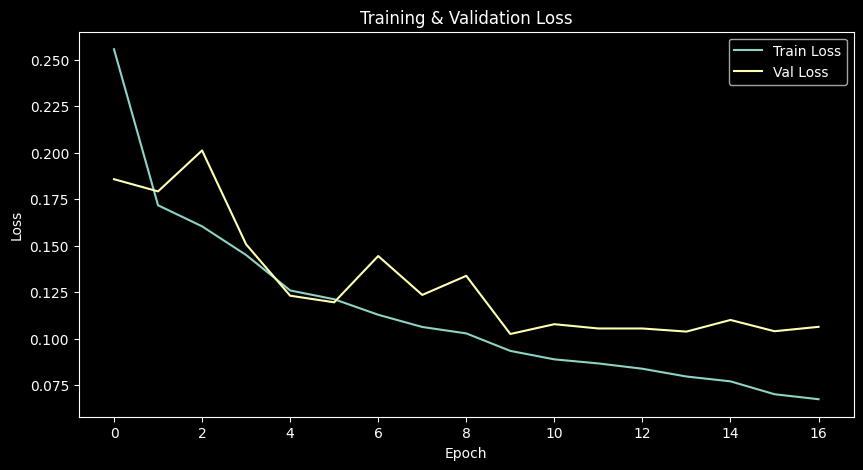

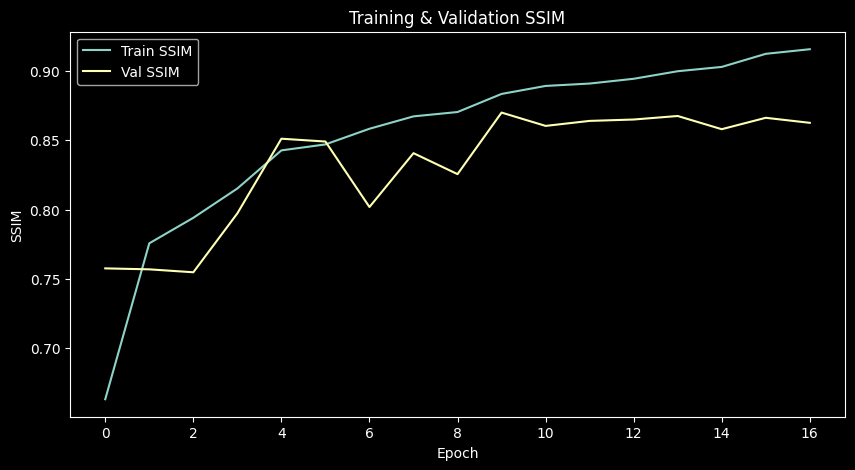

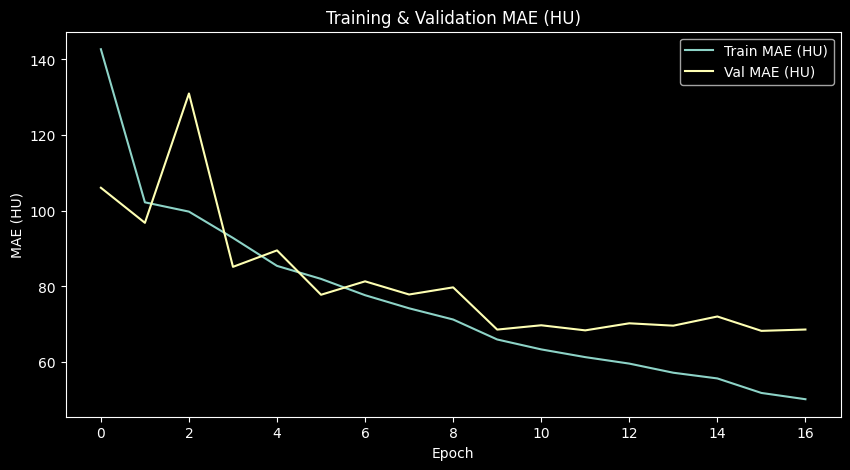

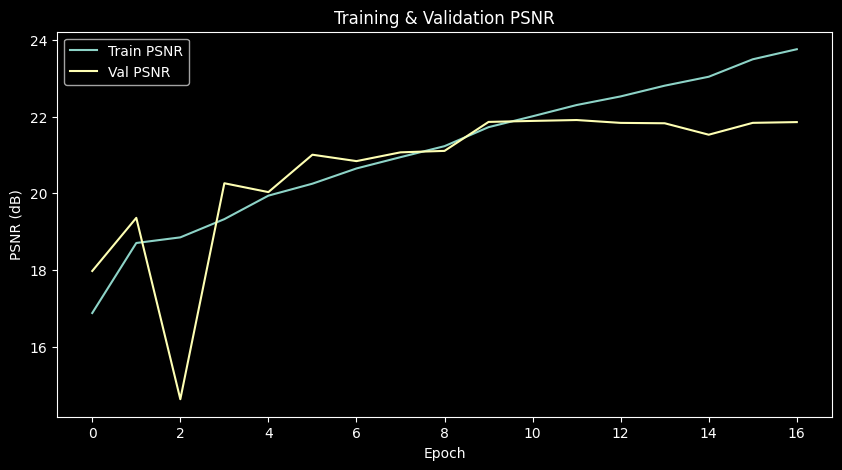

✅ Plots saved as PNG files in: /kaggle/working


In [39]:
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# Load history from checkpoint
checkpoint = torch.load(FINAL_MODEL_PATH, map_location="cpu")
history = checkpoint['history']

# Directory to save plots
out_dir = Path("/kaggle/working")
out_dir.mkdir(exist_ok=True)

# ---------- Plot Loss ----------
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label="Train Loss")
plt.plot(history['val_loss'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.savefig(out_dir / "loss_curve.png", dpi=300)
plt.show()

# ---------- Plot SSIM ----------
plt.figure(figsize=(10, 5))
plt.plot(history['train_ssim'], label="Train SSIM")
plt.plot(history['val_ssim'], label="Val SSIM")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.title("Training & Validation SSIM")
plt.legend()
plt.savefig(out_dir / "ssim_curve.png", dpi=300)
plt.show()

# ---------- Plot MAE (HU) ----------
plt.figure(figsize=(10, 5))
plt.plot(history['train_mae_hu'], label="Train MAE (HU)")
plt.plot(history['val_mae_hu'], label="Val MAE (HU)")
plt.xlabel("Epoch")
plt.ylabel("MAE (HU)")
plt.title("Training & Validation MAE (HU)")
plt.legend()
plt.savefig(out_dir / "mae_hu_curve.png", dpi=300)
plt.show()

# ---------- Plot PSNR ----------
plt.figure(figsize=(10, 5))
plt.plot(history['train_psnr'], label="Train PSNR")
plt.plot(history['val_psnr'], label="Val PSNR")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("Training & Validation PSNR")
plt.legend()
plt.savefig(out_dir / "psnr_curve.png", dpi=300)
plt.show()

print("✅ Plots saved as PNG files in:", out_dir)


In [12]:
import os
from pathlib import Path

# Check what's in your working directory
print("=== Files in /kaggle/working ===")
working_files = os.listdir('/kaggle/working')
for file in sorted(working_files):
    file_path = Path('/kaggle/working') / file
    if file_path.is_file():
        size_mb = file_path.stat().st_size / (1024*1024)
        print(f"📄 {file} ({size_mb:.1f} MB)")
    elif file_path.is_dir():
        print(f"📁 {file}/")

# Check specifically for checkpoints directory
checkpoint_dir = Path('/kaggle/working/checkpoints')
if checkpoint_dir.exists():
    print(f"\n=== Checkpoints in {checkpoint_dir} ===")
    checkpoint_files = os.listdir(checkpoint_dir)
    for file in sorted(checkpoint_files):
        file_path = checkpoint_dir / file
        size_mb = file_path.stat().st_size / (1024*1024)
        print(f"💾 {file} ({size_mb:.1f} MB)")
    print(f"\nTotal checkpoints saved: {len(checkpoint_files)}")
else:
    print("\n❌ No checkpoints directory found")

# Check for model files
model_files = [f for f in working_files if f.endswith('.pth')]
if model_files:
    print(f"\n=== Model Files ===")
    for model_file in model_files:
        file_path = Path('/kaggle/working') / model_file
        size_mb = file_path.stat().st_size / (1024*1024)
        print(f"🤖 {model_file} ({size_mb:.1f} MB)")


=== Files in /kaggle/working ===
📁 .ipynb_checkpoints/
📁 .virtual_documents/
📄 best_mri_to_ct_model.pth (355.7 MB)
📁 checkpoints/
📁 checkpoints_fixed/
📄 final_mri_to_ct_model.pth (355.7 MB)
📁 processed_slices/

=== Checkpoints in /kaggle/working/checkpoints ===
💾 checkpoint_epoch_10.pth (355.7 MB)
💾 checkpoint_epoch_12.pth (355.7 MB)
💾 checkpoint_epoch_14.pth (355.7 MB)
💾 checkpoint_epoch_16.pth (355.7 MB)
💾 checkpoint_epoch_2.pth (355.7 MB)
💾 checkpoint_epoch_4.pth (355.7 MB)
💾 checkpoint_epoch_6.pth (355.7 MB)
💾 checkpoint_epoch_8.pth (355.7 MB)

Total checkpoints saved: 8

=== Model Files ===
🤖 best_mri_to_ct_model.pth (355.7 MB)
🤖 final_mri_to_ct_model.pth (355.7 MB)


In [13]:
# Load and inspect your best model
best_model_path = Path('/kaggle/working/best_mri_to_ct_model.pth')
checkpoint = torch.load(best_model_path, map_location='cpu')

print("🏆 BEST MODEL PERFORMANCE SUMMARY:")
print("="*50)
print(f"📅 Best Epoch: {checkpoint.get('epoch', 'Unknown')}")
print(f"📈 Best Validation SSIM: {checkpoint.get('val_ssim', 'Unknown'):.6f}")
print(f"📉 Best Validation Loss: {checkpoint.get('val_loss', 'Unknown'):.6f}")
print(f"🎯 Training SSIM: {checkpoint.get('train_ssim', 'Unknown'):.6f}")
print(f"💾 Model Size: 355.7 MB")

# Check hyperparameters used
if 'hyperparameters' in checkpoint:
    hp = checkpoint['hyperparameters']
    print(f"\n⚙️ HYPERPARAMETERS USED:")
    print(f"   Learning Rate: {hp.get('learning_rate', 'Unknown')}")
    print(f"   Batch Size: {hp.get('batch_size', 'Unknown')}")
    print(f"   Total Epochs: {hp.get('num_epochs', 'Unknown')}")


🏆 BEST MODEL PERFORMANCE SUMMARY:
📅 Best Epoch: 10
📈 Best Validation SSIM: 0.869983
📉 Best Validation Loss: 0.102466
🎯 Training SSIM: 0.883423
💾 Model Size: 355.7 MB

⚙️ HYPERPARAMETERS USED:
   Learning Rate: 0.0002
   Batch Size: 16
   Total Epochs: 20


In [29]:
import torch
import torch.nn.functional as F

def ssim(img1: torch.Tensor, img2: torch.Tensor, window_size: int = 11) -> torch.Tensor:
    """
    Computes mean SSIM for a batch of [B,1,H,W] images in [0,1].
    """
    def gaussian(window_size, sigma=1.5):
        coords = torch.arange(window_size, dtype=img1.dtype, device=img1.device) - window_size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / g.sum()
        return g[:, None] * g[None, :]

    window = gaussian(window_size).unsqueeze(0).unsqueeze(0)
    mu1 = F.conv2d(img1, window, padding=window_size//2)
    mu2 = F.conv2d(img2, window, padding=window_size//2)
    mu1_sq, mu2_sq, mu1_mu2 = mu1**2, mu2**2, mu1*mu2
    sigma1_sq = F.conv2d(img1*img1, window, padding=window_size//2) - mu1_sq
    sigma2_sq = F.conv2d(img2*img2, window, padding=window_size//2) - mu2_sq
    sigma12 = F.conv2d(img1*img2, window, padding=window_size//2) - mu1_mu2
    C1, C2 = 0.01**2, 0.03**2
    ssim_map = ((2*mu1_mu2 + C1)*(2*sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1)*(sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean()


In [31]:
def comprehensive_evaluation(ct_gt: torch.Tensor,
                             ct_pred: torch.Tensor) -> dict:
    """
    Compute MAE, SSIM, and PSNR for a single prediction.
    Inputs expected in [0,1].
    """
    if ct_gt.ndim == 3:
        ct_gt = ct_gt.unsqueeze(0)
    if ct_pred.ndim == 3:
        ct_pred = ct_pred.unsqueeze(0)

    mae = torch.mean(torch.abs(ct_pred - ct_gt)).item()
    ssim_val = ssim(ct_pred, ct_gt).item()      # now ssim is defined
    mse = torch.mean((ct_pred - ct_gt) ** 2)
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8)).item()

    return {"MAE": mae, "SSIM": ssim_val, "PSNR": psnr}


def quick_evaluation(model, val_dataset, device, sample_idx=0):
    """Quick evaluation on a single validation sample."""
    model.eval()
    mri, ct_gt = val_dataset[sample_idx]
    mri = mri.unsqueeze(0).to(device)
    ct_gt = ct_gt.unsqueeze(0).to(device)

    with torch.no_grad():
        ct_pred = model(mri)
        metrics = comprehensive_evaluation(ct_gt, ct_pred)

    print(f"Sample {sample_idx} Evaluation:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.6f}")

    return metrics

quick_evaluation(model, val_dataset, device, sample_idx=5)



Sample 5 Evaluation:
MAE: 0.027924
SSIM: 0.847611
PSNR: 22.940922


{'MAE': 0.02792416885495186,
 'SSIM': 0.8476110696792603,
 'PSNR': 22.940921783447266}

✅ Final test results saved to /kaggle/working/results_test.json
MAE : 0.0240
SSIM: 0.8725
PSNR: 25.17 dB


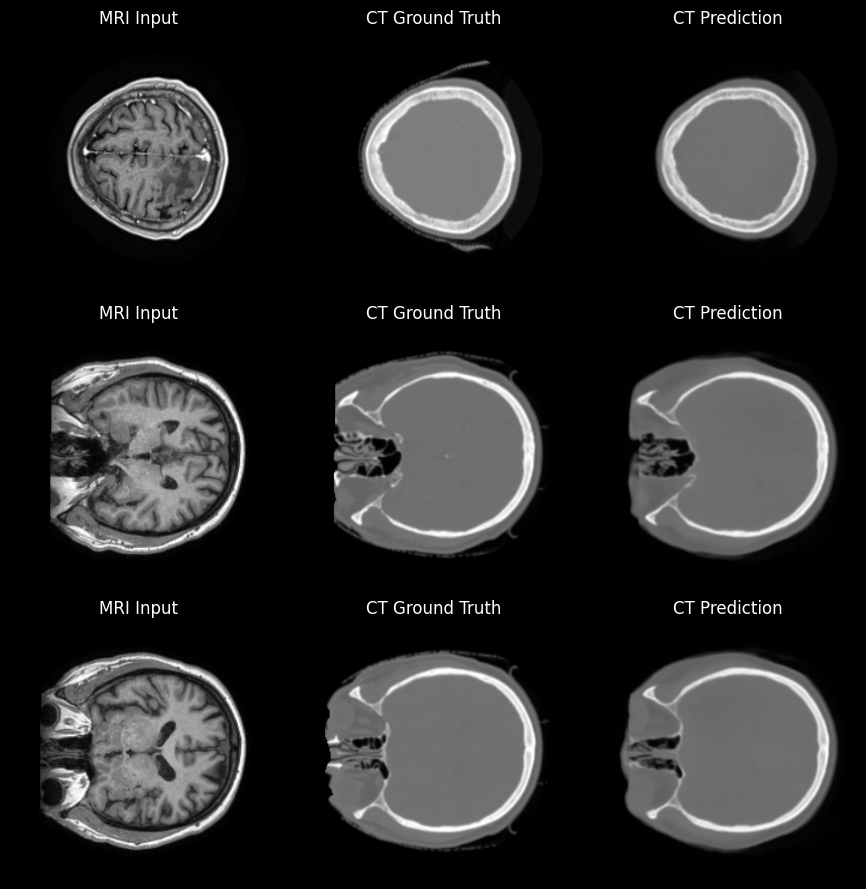

In [37]:
import json, random
from pathlib import Path
import torch
import matplotlib.pyplot as plt

BEST_MODEL_PATH = Path("/kaggle/working/best_mri_to_ct_model.pth")
RESULTS_JSON   = Path("/kaggle/working/results_test.json")

# ---- Load Best Model ----
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

# ---- Evaluate on Test Set ----
all_mae, all_ssim, all_psnr = [], [], []
with torch.no_grad():
    for mri, ct_gt in test_loader:
        mri, ct_gt = mri.to(device), ct_gt.to(device)
        ct_pred = model(mri)

        metrics = comprehensive_evaluation(ct_gt, ct_pred)
        all_mae.append(metrics["MAE"])
        all_ssim.append(metrics["SSIM"])
        all_psnr.append(metrics["PSNR"])

results = {
    "MAE":  sum(all_mae)  / len(all_mae),
    "SSIM": sum(all_ssim) / len(all_ssim),
    "PSNR": sum(all_psnr) / len(all_psnr),
}

# ---- Save metrics to JSON ----
with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=4)

print(f"✅ Final test results saved to {RESULTS_JSON}")
print(f"MAE : {results['MAE']:.4f}")
print(f"SSIM: {results['SSIM']:.4f}")
print(f"PSNR: {results['PSNR']:.2f} dB")

# ---- Random Visualizations ----
def visualize_random_samples(model, dataset, device, num_samples=3):
    """Show random MRI / GroundTruth CT / Predicted CT triplets."""
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(9, 3 * num_samples))
    for i, idx in enumerate(indices):
        mri, ct_gt = dataset[idx]
        mri = mri.unsqueeze(0).to(device)
        with torch.no_grad():
            ct_pred = model(mri).cpu().squeeze(0)

        mri = mri.cpu().squeeze(0)
        ct_gt = ct_gt.cpu().squeeze(0)

        # Plot row with 3 columns
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(mri.squeeze(0).cpu(), cmap="gray")
        plt.title("MRI Input")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(ct_gt.squeeze(0).cpu(), cmap="gray")
        plt.title("CT Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(ct_pred.squeeze(0).cpu(), cmap="gray")
        plt.title("CT Prediction")
        plt.axis("off")


    plt.tight_layout()
    plt.show()

# Display 3 random test samples
visualize_random_samples(model, test_dataset, device, num_samples=3)

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, peak_signal_noise_ratio

def run_comprehensive_evaluation(save_images=True, save_dir="/kaggle/working/test_results"):
    model.eval()
    os.makedirs(save_dir, exist_ok=True)

    ssim_scores, psnr_scores, mae_scores = [], [], []
    per_sample = []

    with torch.no_grad():
        for idx, (mri, ct) in enumerate(test_loader):
            mri, ct = mri.to(device), ct.to(device)

            # Forward pass
            pred_ct = model(mri)

            # Convert to numpy
            mri_np  = mri.squeeze().cpu().numpy()
            ct_np   = ct.squeeze().cpu().numpy()
            pred_np = pred_ct.squeeze().cpu().numpy()

            # Ensure 2D arrays
            def make_2d(x):
                x = np.squeeze(x)
                return x[0] if x.ndim > 2 else x
            
            mri_img  = make_2d(mri_np)
            ct_img   = make_2d(ct_np)
            pred_img = make_2d(pred_np)

            # --- Compute metrics ---
            ssim_val = structural_similarity(pred_img, ct_img, data_range=ct_img.max() - ct_img.min())
            psnr_val = peak_signal_noise_ratio(ct_img, pred_img, data_range=ct_img.max() - ct_img.min())
            mae_val  = np.mean(np.abs(pred_img - ct_img))

            ssim_scores.append(ssim_val)
            psnr_scores.append(psnr_val)
            mae_scores.append(mae_val)

            per_sample.append({
                "index": idx,
                "SSIM": float(ssim_val),
                "PSNR": float(psnr_val),
                "MAE_HU": float(mae_val)
            })

            # --- Save side-by-side visualization ---
            if save_images and idx < 50:  # limit to first 50
                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(mri_img, cmap="gray")
                axs[0].set_title("MRI Input")
                axs[0].axis("off")

                axs[1].imshow(ct_img, cmap="gray")
                axs[1].set_title("Ground Truth CT")
                axs[1].axis("off")

                axs[2].imshow(pred_img, cmap="gray")
                axs[2].set_title(f"Predicted CT\nSSIM={ssim_val:.3f}, PSNR={psnr_val:.2f}")
                axs[2].axis("off")

                plt.tight_layout()
                plt.savefig(os.path.join(save_dir, f"sample_{idx:03d}.png"))
                plt.close()

    # Aggregate metrics
    results = {
        "SSIM": float(np.mean(ssim_scores)),
        "PSNR": float(np.mean(psnr_scores)),
        "MAE_HU": float(np.mean(mae_scores)),
        "per_sample": per_sample
    }
    return results

with torch.no_grad():
    results = run_comprehensive_evaluation()

